In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import datetime
from scipy import stats

In [2]:
filepath = r"C:\Users\venta\Documents\Grad Plans\portfolio\Quantium\QVI_data.csv"
df = pd.read_csv(filepath, header=0)
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Chip Compny SeaSalt,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,Nacho Cheese,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Crinkle Cut Chips Chicken,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Chip Thinly S/Cream&Onion,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Tortilla ChpsHny&Jlpno Chili,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [3]:
df.info() #checking date format
#making yyyymm column
df['DATE'] = pd.to_datetime(df['DATE'])
df['YEARMONTH'] = df['DATE'].dt.strftime('%Y%m').astype(int)
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 246740 entries, 0 to 246739
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              246740 non-null  str    
 1   STORE_NBR         246740 non-null  int64  
 2   LYLTY_CARD_NBR    246740 non-null  int64  
 3   TXN_ID            246740 non-null  int64  
 4   PROD_NBR          246740 non-null  int64  
 5   PROD_NAME         246740 non-null  str    
 6   PROD_QTY          246740 non-null  int64  
 7   TOT_SALES         246740 non-null  float64
 8   PACK_SIZE         246740 non-null  float64
 9   BRAND             246740 non-null  str    
 10  LIFESTAGE         246740 non-null  str    
 11  PREMIUM_CUSTOMER  246740 non-null  str    
dtypes: float64(2), int64(5), str(5)
memory usage: 22.6 MB


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,2018-10-17,1,1000,1,5,Chip Compny SeaSalt,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium,201810
1,2019-05-14,1,1307,348,66,Nacho Cheese,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget,201905
2,2019-05-20,1,1343,383,61,Crinkle Cut Chips Chicken,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget,201905
3,2018-08-17,2,2373,974,69,Chip Thinly S/Cream&Onion,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget,201808
4,2018-08-18,2,2426,1038,108,Tortilla ChpsHny&Jlpno Chili,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget,201808


In [4]:
#defining measure calculations for each store and month
#total sales, number of customers, transactions per customer, chips per customer
#and avg price per unit. calc agg of sums and counts first
measures = df.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    totSales = ('TOT_SALES', 'sum'),
    nCustomers = ('LYLTY_CARD_NBR', 'nunique'),
    nChips = ('PROD_QTY', 'sum'),
    nTxn = ('TXN_ID', 'nunique')
).reset_index()
#calc avgs
measures['nTxnPerCust'] = measures['nTxn']/measures['nCustomers']
measures['nChipsPerCust'] = measures['nChips']/measures['nCustomers']
measures['AvgPricePerUnit'] = measures['totSales']/measures['nChips']
print(measures.head())
print(measures.shape)

   STORE_NBR  YEARMONTH  totSales  nCustomers  nChips  nTxn  nTxnPerCust  \
0          1     201807     188.9          47      58    49     1.042553   
1          1     201808     168.4          41      52    41     1.000000   
2          1     201809     268.1          57      71    59     1.035088   
3          1     201810     175.4          39      51    40     1.025641   
4          1     201811     184.8          44      55    45     1.022727   

   nChipsPerCust  AvgPricePerUnit  
0       1.234043         3.256897  
1       1.268293         3.238462  
2       1.245614         3.776056  
3       1.307692         3.439216  
4       1.250000         3.360000  
(3165, 9)


In [5]:
#locate stores with full 12 month obs
store_month_counts = measures['STORE_NBR'].value_counts()
stores_FullObs = store_month_counts[store_month_counts == 12].index
#then separate pretrial window
preTrial_measures = measures[(measures['STORE_NBR'].isin(stores_FullObs)) & (measures['YEARMONTH'] <201902)]
preTrial_measures.shape

(1813, 9)

In [6]:
#function for correlation calculating for control stores
def calculateCorrelation(inputTable, metricCol, storeComparison):
    results = [] #empty list
    storeNumbers = inputTable['STORE_NBR'].unique() #grabs list of unique store #
    for store in storeNumbers:
        trial_data = inputTable[inputTable['STORE_NBR'] == storeComparison][metricCol].reset_index(drop=True)
        control_data = inputTable[inputTable['STORE_NBR'] == store][metricCol].reset_index(drop=True)
        if len(trial_data) == 7 and len(control_data) == 7:
            correlation = trial_data.corr(control_data)
        else:
            correlation = None #makes sure both have 7 months of data
        results.append({
            'Store1': storeComparison,
            'Store2': store,
            'corr_measure': correlation
        })
    return results

In [7]:
def calculateMagnitudeDistance(inputTable, metricCol, storeComparison):
    results = []
    storeNumbers = inputTable['STORE_NBR'].unique()
    
    for store in storeNumbers:
        trial_data = inputTable[inputTable['STORE_NBR'] == storeComparison].sort_values('YEARMONTH').reset_index(drop=True)
        control_data = inputTable[inputTable['STORE_NBR'] == store].sort_values('YEARMONTH').reset_index(drop=True)
        if len(trial_data) == 7 and len(control_data) == 7:
            distance = abs(trial_data[metricCol] - control_data[metricCol])
            for i in range(7):
                results.append({
                    'Store1': storeComparison,
                    'Store2': store,
                    'YEARMONTH': trial_data['YEARMONTH'].iloc[i],
                    'measure': distance.iloc[i]
                })
    dist_df = pd.DataFrame(results)

    #standardization
    min_max = dist_df.groupby(['Store1', 'YEARMONTH'])['measure'].agg(['min', 'max']).reset_index()
    dist_df = pd.merge(dist_df, min_max, on=['Store1', 'YEARMONTH'])
    #formula:
    dist_df['magnitudeMeasure'] = 1 - (dist_df['measure'] - dist_df['min']) / (dist_df['max'] - dist_df['min'])


    #averaging the 7 months to get one final score for every store pair
    finalDistTable = dist_df.groupby(['Store1', 'Store2'])['magnitudeMeasure'].mean().reset_index()
    finalDistTable.rename(columns={'magnitudeMeasure': 'mag_measure'}, inplace=True)

    return finalDistTable


In [8]:
#finding the twin trial store
#correlation function
trial_store = 77
corr_nSales = calculateCorrelation(preTrial_measures, 'totSales', trial_store)
corr_nCustomers = calculateCorrelation(preTrial_measures, 'nCustomers', trial_store)
corr_nSales = pd.DataFrame(corr_nSales)
corr_nCustomers = pd.DataFrame(corr_nCustomers)

#magnitude function
magnitude_nSales = calculateMagnitudeDistance(preTrial_measures, 'totSales', trial_store)
magnitude_nCustomers = calculateMagnitudeDistance(preTrial_measures, 'nCustomers', trial_store)

#checking
print("--- Sales Correlation ---")
print(corr_nSales.head())

print("--- Sales Magnitude ---")
print(magnitude_nSales.head())

--- Sales Correlation ---
   Store1  Store2  corr_measure
0      77       1     -0.005382
1      77       2     -0.251183
2      77       3      0.660447
3      77       4     -0.347846
4      77       5     -0.139048
--- Sales Magnitude ---
   Store1  Store2  mag_measure
0      77       1     0.952537
1      77       2     0.936070
2      77       3     0.344996
3      77       4     0.180850
4      77       5     0.564457


In [9]:
#merging
score_nSales = pd.merge(corr_nSales, magnitude_nSales, on=['Store1', 'Store2'])
score_nSales['scoreControlSales'] = (score_nSales['corr_measure'] * 0.5) + (score_nSales['mag_measure'] * 0.5)
print("--- Score Sales ---")
print(score_nSales.head())

score_nCustomers = pd.merge(corr_nCustomers, magnitude_nCustomers, on=['Store1', 'Store2'])
score_nCustomers['scoreControlCustomers'] = (score_nCustomers['corr_measure'] * 0.5) + (score_nCustomers['mag_measure'] * 0.5)
print("--- Score Customers ---")
print(score_nCustomers.head())
                                     

--- Score Sales ---
   Store1  Store2  corr_measure  mag_measure  scoreControlSales
0      77       1     -0.005382     0.952537           0.473577
1      77       2     -0.251183     0.936070           0.342443
2      77       3      0.660447     0.344996           0.502721
3      77       4     -0.347846     0.180850          -0.083498
4      77       5     -0.139048     0.564457           0.212704
--- Score Customers ---
   Store1  Store2  corr_measure  mag_measure  scoreControlCustomers
0      77       1      0.337866     0.939115               0.638490
1      77       2     -0.596492     0.908732               0.156120
2      77       3      0.755249     0.343159               0.549204
3      77       4     -0.305412     0.202260              -0.051576
4      77       5      0.224768     0.513580               0.369174


In [10]:
#grand merge
score_Control = pd.merge(score_nSales, score_nCustomers, on=['Store1', 'Store2'])
#cleaning column names
score_Control = score_Control.rename(columns={
    'corr_measure_x':'corr_measure_sales',
    'corr_measure_y':'corr_measure_customers',
    'mag_measure_x':'mag_measure_sales',
    'mag_measure_y':'mag_measure_customers'
})
#calculating average
score_Control['finalControlScore'] = (score_Control['scoreControlSales'] * 0.5) + (score_Control['scoreControlCustomers'] * 0.5)

#sorting
score_Control.sort_values('finalControlScore', ascending=False).head()

,Store1,Store2,corr_measure_sales,mag_measure_sales,scoreControlSales,corr_measure_customers,mag_measure_customers,scoreControlCustomers,finalControlScore
72,77,77,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
220,77,233,0.973643,0.985897,0.979770,0.965682,0.990963,0.978323,0.979046
46,77,50,0.897701,0.974384,0.936042,0.709398,0.931990,0.820694,0.878368
32,77,35,0.691090,0.907671,0.799380,0.892741,0.899561,0.896151,0.847766
240,77,254,0.584873,0.920966,0.752919,0.901610,0.929504,0.915557,0.834238


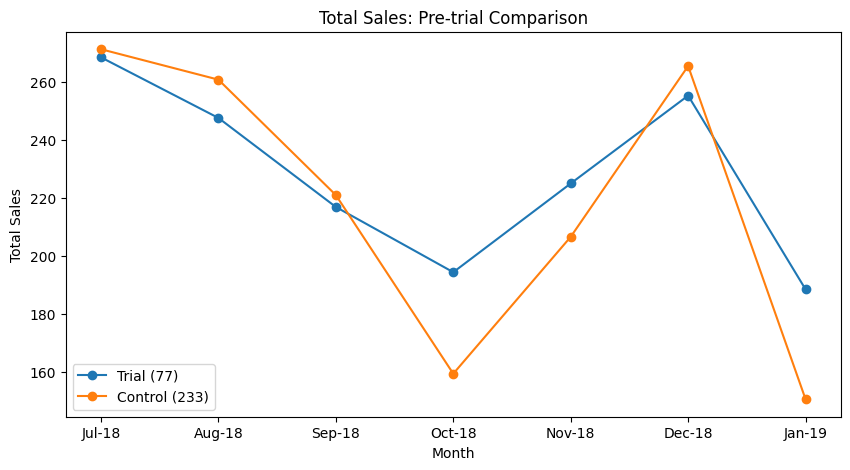

In [11]:
#visual verification of sales comparisons
#isolating the two stores
trial_plot = preTrial_measures[preTrial_measures['STORE_NBR'] == 77]
control_plot = preTrial_measures[preTrial_measures['STORE_NBR'] == 233]

#converting yearmonth to string
trial_plot['YEARMONTH'] = trial_plot['YEARMONTH'].astype(str)
control_plot['YEARMONTH'] = control_plot['YEARMONTH'].astype(str)
pretty_dates = [datetime.datetime.strptime(str(x), '%Y%m').strftime('%b-%y') for x in trial_plot['YEARMONTH']]

#plotting
plt.figure(figsize=(10, 5))
plt.plot(pretty_dates, trial_plot['totSales'], label='Trial (77)', marker='o')
plt.plot(pretty_dates, control_plot['totSales'], label='Control (233)', marker='o')

plt.title('Total Sales: Pre-trial Comparison')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.show()


In [14]:
#exporting for excel
export_df = pd.DataFrame({
    'Month': pretty_dates,
    'Trial_77_Sales': trial_plot['totSales'].values,
    'Control_233_Sales': control_plot['totSales'].values
})
export_df.to_csv('trial_vs_control_sales_77.csv', index=False)

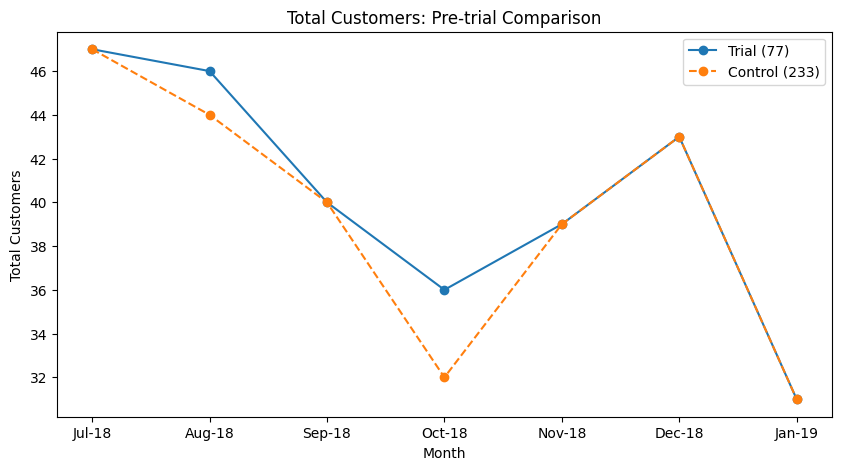

In [17]:
#visual verification of customer comparisons

#plotting
plt.figure(figsize=(10, 5))
plt.plot(pretty_dates, trial_plot['nCustomers'], label='Trial (77)', marker='o')
plt.plot(pretty_dates, control_plot['nCustomers'], label='Control (233)', marker='o', linestyle='--')

plt.title('Total Customers: Pre-trial Comparison')
plt.xlabel('Month')
plt.ylabel('Total Customers')
plt.legend()
plt.show()


In [20]:
#exporting for excel
export_df_customers = pd.DataFrame({
    'Month': pretty_dates,
    'Trial_77_Customers': trial_plot['nCustomers'].values,
    'Control_233_Customers': control_plot['nCustomers'].values
})
export_df_customers.to_csv('trial_vs_control_customers_77.csv', index=False)

In [21]:
#scaling factor
trial_sum = preTrial_measures[preTrial_measures['STORE_NBR'] == trial_store]['totSales'].sum()
control_sum = preTrial_measures[preTrial_measures['STORE_NBR'] == 233]['totSales'].sum()

#ratio
scaling_factor = trial_sum/control_sum
print(f"Scaling Factor: {scaling_factor}")

#applying scaling factor
#grab every month of control store
controlSales = measures[measures['STORE_NBR'] == 233].copy()
#create scaled column
controlSales['controlSales'] = controlSales['totSales'] * scaling_factor
controlSales[['YEARMONTH', 'totSales', 'controlSales']].head()

Scaling Factor: 1.0397523623330076


,YEARMONTH,totSales,controlSales
2695,201807,271.2,281.980841
2696,201808,260.7,271.063441
2697,201809,220.9,229.681297
2698,201810,159.3,165.632551
2699,201811,206.5,214.708863


In [22]:
#grabbing trial store 77 data
trialSales = measures[measures['STORE_NBR'] == trial_store][['YEARMONTH', 'totSales']]
trialSales = trialSales.rename(columns={'totSales':'trialSales'})
#merge
percentageDiff_sales = pd.merge(trialSales, controlSales[['YEARMONTH', 'controlSales']], on='YEARMONTH')

#calculate
percentageDiff_sales['percentageDiff'] = (percentageDiff_sales['trialSales'] - percentageDiff_sales['controlSales']) / percentageDiff_sales['controlSales']

percentageDiff_sales.head()

,YEARMONTH,trialSales,controlSales,percentageDiff
0,201807,268.4,281.980841,-0.048162
1,201808,247.5,271.063441,-0.086930
2,201809,216.8,229.681297,-0.056083
3,201810,194.3,165.632551,0.173079
4,201811,224.9,214.708863,0.047465


In [23]:
stdDev_sales = percentageDiff_sales[percentageDiff_sales['YEARMONTH'] < 201902]['percentageDiff'].std()
#t value where null is u=0
percentageDiff_sales['tValue'] = percentageDiff_sales['percentageDiff'] / stdDev_sales
#crit val w 95th percentile and 7 deg of freedom (8 months in pretrial period)
critical_value = stats.t.ppf(0.95, df=7)
print(f"Critical Value: {critical_value}")

Critical Value: 1.8945786050900062


In [24]:
#comparing crit val
trial_months = [201903, 201904, 201905]
trial_results = percentageDiff_sales[percentageDiff_sales['YEARMONTH'].isin(trial_months)]
trial_results['Significant'] = abs(trial_results['tValue']) > critical_value
print(trial_results[['YEARMONTH', 'percentageDiff', 'tValue', 'Significant']])

    YEARMONTH  percentageDiff    tValue  Significant
8      201903        0.358510  2.945026         True
9      201904        0.721444  5.926392         True
10     201905       -0.160880 -1.321571        False


In [25]:
#--------interpretations---------
#the experiment increased sales by ~35.9% in March and ~72.1% in April, 
#which are statistically significant differences at the 95% confidence level, 
#but in May, the difference between trial and control store sales descreases by ~16%, 
#which is not a significant value at the same confidence level


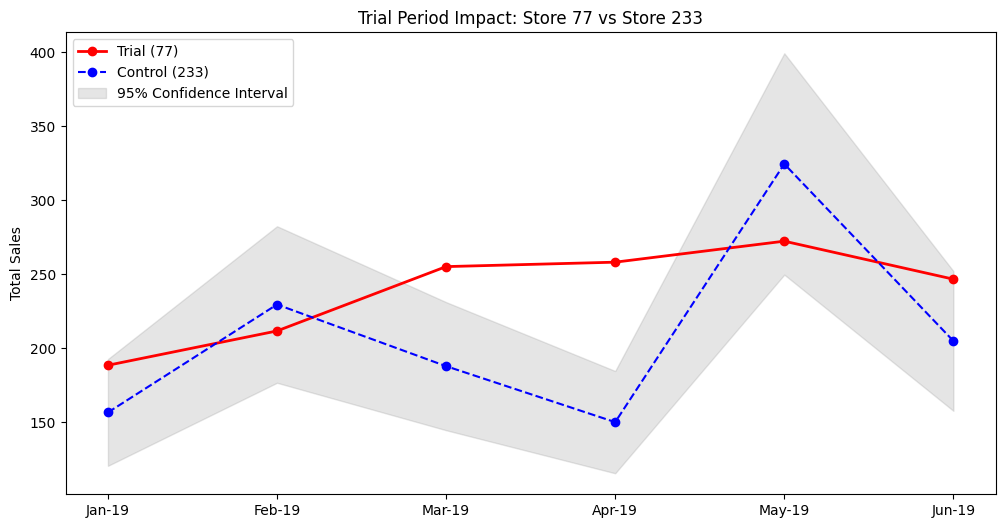

In [26]:
#plotting 95% confidence
#calculate bounds
percentageDiff_sales['Control_Upper_95'] = percentageDiff_sales['controlSales'] * (1 + (stdDev_sales * critical_value))
percentageDiff_sales['Control_Lower_5'] = percentageDiff_sales['controlSales'] * (1 - (stdDev_sales * critical_value))

#filter report window jan 2019 -- may 2019
report_df = percentageDiff_sales[percentageDiff_sales['YEARMONTH'] >= 201901]
pretty_dates_report = [datetime.datetime.strptime(str(x), '%Y%m').strftime('%b-%y') for x in report_df['YEARMONTH']]

#plot
plt.figure(figsize=(12, 6))
plt.plot(pretty_dates_report, report_df['trialSales'], label='Trial (77)', marker='o', color='red', linewidth=2)
plt.plot(pretty_dates_report, report_df['controlSales'], label='Control (233)', marker='o', color='blue', linestyle='--')

#adding 95% region
plt.fill_between(pretty_dates_report, report_df['Control_Lower_5'], report_df['Control_Upper_95'],
                 color='gray', alpha=0.2, label='95% Confidence Interval')
plt.title('Trial Period Impact: Store 77 vs Store 233')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

In [35]:
#exporting for excel
export_posttrial_df = pd.DataFrame({
    'Month': pretty_dates_report,
    'Trial Sales (77)': report_df['trialSales'].values,
    'Control Sales (233)': report_df['controlSales'].values,
    'Lower CI Bound': report_df['Control_Lower_5'].values,
    'Upper CI Bound': report_df['Control_Upper_95'].values
})
export_posttrial_df.to_csv('posttrial_vs_control_sales.csv', index=False)

In [36]:
#------customers store 77
#scaling factor
trial_sum_cust = preTrial_measures[preTrial_measures['STORE_NBR'] == trial_store]['nCustomers'].sum()
control_sum_cust = preTrial_measures[preTrial_measures['STORE_NBR'] == 233]['nCustomers'].sum()

#ratio
scaling_factor_cust = trial_sum_cust/control_sum_cust
print(f"Scaling Factor: {scaling_factor_cust}")

#applying scaling factor
#grab every month of control store
controlCustomers = measures[measures['STORE_NBR'] == 233].copy()
#create scaled column
controlCustomers['controlCustomers'] = controlCustomers['nCustomers'] * scaling_factor_cust
controlCustomers[['YEARMONTH', 'nCustomers', 'controlCustomers']].head()

Scaling Factor: 1.0217391304347827


,YEARMONTH,nCustomers,controlCustomers
2695,201807,47,48.021739
2696,201808,44,44.956522
2697,201809,40,40.869565
2698,201810,32,32.695652
2699,201811,39,39.847826


In [37]:
#percentageDiff customers
#grabbing trial store 77 data
trialCustomers = measures[measures['STORE_NBR'] == trial_store][['YEARMONTH', 'nCustomers']]
trialCustomers = trialCustomers.rename(columns={'nCustomers':'trialCustomers'})
#merge
percentageDiff_cust = pd.merge(trialCustomers, controlCustomers[['YEARMONTH', 'controlCustomers']], on='YEARMONTH')

#calculate
percentageDiff_cust['percentageDiff'] = (percentageDiff_cust['trialCustomers'] - percentageDiff_cust['controlCustomers']) / percentageDiff_cust['controlCustomers']

percentageDiff_cust.head()

,YEARMONTH,trialCustomers,controlCustomers,percentageDiff
0,201807,47,48.021739,-0.021277
1,201808,46,44.956522,0.023211
2,201809,40,40.869565,-0.021277
3,201810,36,32.695652,0.101064
4,201811,39,39.847826,-0.021277


In [38]:
stdDev_cust = percentageDiff_cust[percentageDiff_cust['YEARMONTH'] < 201902]['percentageDiff'].std()
#t value where null is u=0
percentageDiff_cust['tValue'] = percentageDiff_cust['percentageDiff'] / stdDev_cust

In [39]:
#comparing crit val customers
trial_results_cust = percentageDiff_cust[percentageDiff_cust['YEARMONTH'].isin(trial_months)]
trial_results_cust['Significant'] = abs(trial_results_cust['tValue']) > critical_value
print(trial_results_cust[['YEARMONTH', 'percentageDiff', 'tValue', 'Significant']])

    YEARMONTH  percentageDiff     tValue  Significant
8      201903        0.286322   6.158208         True
9      201904        0.703704  15.135234         True
10     201905       -0.039401  -0.847438        False


In [40]:
#--------interpretations---------
#the experiment increased customer foot traffic by ~28.6% in March and ~70.4% in April, 
#which are statistically significant increases at the 95% confidence level, 
#but in May, the difference between trial and control store customer foot traffic drops by ~3.9%, 
#which is not a significant value at the same confidence level

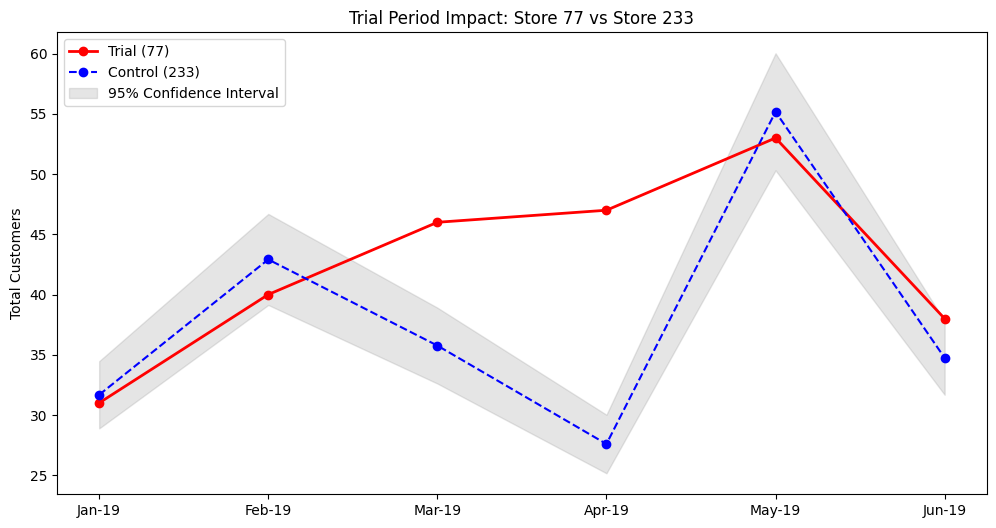

In [41]:
#plotting 95% confidence
#calculate bounds
percentageDiff_cust['Control_Upper_95'] = percentageDiff_cust['controlCustomers'] * (1 + (stdDev_cust * critical_value))
percentageDiff_cust['Control_Lower_5'] = percentageDiff_cust['controlCustomers'] * (1 - (stdDev_cust * critical_value))

#filter report window jan 2019 -- may 2019
report_cust_df = percentageDiff_cust[percentageDiff_cust['YEARMONTH'] >= 201901]
pretty_dates_report_cust = [datetime.datetime.strptime(str(x), '%Y%m').strftime('%b-%y') for x in report_cust_df['YEARMONTH']]

#plot
plt.figure(figsize=(12, 6))
plt.plot(pretty_dates_report_cust, report_cust_df['trialCustomers'], label='Trial (77)', marker='o', color='red', linewidth=2)
plt.plot(pretty_dates_report_cust, report_cust_df['controlCustomers'], label='Control (233)', marker='o', color='blue', linestyle='--')

#adding 95% region
plt.fill_between(pretty_dates_report_cust, report_cust_df['Control_Lower_5'], report_cust_df['Control_Upper_95'],
                 color='gray', alpha=0.2, label='95% Confidence Interval')
plt.title('Trial Period Impact: Store 77 vs Store 233')
plt.ylabel('Total Customers')
plt.legend()
plt.show()

In [43]:
#exporting for excel
export_posttrial_df_cust = pd.DataFrame({
    'Month': pretty_dates_report_cust,
    'Trial Sales (77)': report_cust_df['trialCustomers'].values,
    'Control Sales (233)': report_cust_df['controlCustomers'].values,
    'Lower CI Bound': report_cust_df['Control_Lower_5'].values,
    'Upper CI Bound': report_cust_df['Control_Upper_95'].values
})
export_posttrial_df_cust.to_csv('posttrial_vs_control_customers.csv', index=False)